# ResNet Exploration — DeepFake Detection

**ResNet-18 vs ResNet-34** | wiki (real) vs inpainting (fake) | Optuna hyperparameter optimisation

> **Quick-test mode** — uses 2 train folds + 1 test fold (~900 images total) so the full notebook runs in ~2 minutes on GPU.

## 1 · Imports & Setup

In [5]:
from config import *
from utils import *

from torchvision.models import resnet18, resnet34
from sklearn.metrics import (
    confusion_matrix, f1_score, recall_score,
    precision_score, accuracy_score, classification_report
)
import optuna
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

%load_ext autoreload
%autoreload 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2 · Dataset

| Split | Folds | ~Images |
|-------|-------|--------|
| train | 0–1   | 600    |
| test  | 2     | 300    |

Bump `TRAIN_FOLDS` / `TEST_FOLDS` for a fuller run once everything checks out.

In [6]:
TRAIN_FOLDS = [0,  80]   # folds 00–79 → ~80 %  (~45 k images)
TEST_FOLDS  = [80, 100]  # folds 80–99 → ~20 %  (~11 k images)

train_ds = ConcatDataset([
    DeepFakeDataset(WIKI_DIR,       0, range_folds=TRAIN_FOLDS),
    DeepFakeDataset(INPAINTING_DIR, 1, range_folds=TRAIN_FOLDS),
])
test_ds = ConcatDataset([
    DeepFakeDataset(WIKI_DIR,       0, range_folds=TEST_FOLDS),
    DeepFakeDataset(INPAINTING_DIR, 1, range_folds=TEST_FOLDS),
])

print(f"train: {len(train_ds):,}  |  test: {len(test_ds):,}")

Building ../deepfake_data/wiki dataset with 80 folds: 100%|██████████| 80/80 [00:00<00:00, 883.98it/s]
Building ../deepfake_data/inpainting dataset with 80 folds: 100%|██████████| 80/80 [00:00<00:00, 893.88it/s]
Building ../deepfake_data/wiki dataset with 20 folds: 100%|██████████| 20/20 [00:00<00:00, 869.66it/s]
Building ../deepfake_data/inpainting dataset with 20 folds: 100%|██████████| 20/20 [00:00<00:00, 888.86it/s]

train: 48,004  |  test: 11,996


## 3 · Helpers

In [7]:
def get_model(name, dropout=0.0):
    builders = {"resnet18": resnet18, "resnet34": resnet34}
    m = builders[name](weights=None)
    in_f = m.fc.in_features
    m.fc = (nn.Sequential(nn.Dropout(dropout), nn.Linear(in_f, 2))
            if dropout > 0 else nn.Linear(in_f, 2))
    return m.to(device)

def make_loaders(batch_size):
    kw = dict(num_workers=0, pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw),
    )

def make_optimizer(name, params, lr, weight_decay):
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    for images, labels, _, _ in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_labels, all_preds = [], []
    total_loss, total = 0.0, 0
    for images, labels, _, _ in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        total_loss += criterion(outputs, labels).item() * images.size(0)
        total      += labels.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
    return total_loss / total, all_labels, all_preds

def compute_metrics(y_true, y_pred):
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
    }

## 4 · Optuna Optimisation

**Full dataset** (80/20 split). Search space per trial:

| Param | Range |
|---|---|
| `lr` | log-uniform [1e-5, 1e-2] |
| `weight_decay` | log-uniform [1e-6, 1e-2] |
| `batch_size` | {128, 256, 512} |
| `optimizer` | {adam, adamw} |
| `dropout` | uniform [0.0, 0.5] |
| `label_smoothing` | uniform [0.0, 0.2] |

Objective: **val F1** after `OPTUNA_EPOCHS` epochs. Sampler: **TPE** (Bayesian). Pruner: **Median** — weak trials are cut early.

> **1.5 h run**: `N_TRIALS=40, OPTUNA_EPOCHS=20` · **Overnight**: `N_TRIALS=100, OPTUNA_EPOCHS=30`

In [8]:
# ── 1.5 h meeting run ──────────────────────────────────────────
N_TRIALS      = 1   # overnight hard version → 100
OPTUNA_EPOCHS = 2   # overnight hard version → 30
# ───────────────────────────────────────────────────────────────

def make_objective(model_name):
    def objective(trial):
        lr               = trial.suggest_float("lr",               1e-5, 1e-2, log=True)
        weight_decay     = trial.suggest_float("weight_decay",     1e-6, 1e-2, log=True)
        batch_size       = trial.suggest_categorical("batch_size", [512, 1024, 1024])
        optimizer_name   = trial.suggest_categorical("optimizer",  ["adam", "adamw"])
        dropout          = trial.suggest_float("dropout",          0.0, 0.5)
        label_smoothing  = trial.suggest_float("label_smoothing",  0.0, 0.2)

        train_loader, val_loader = make_loaders(batch_size)
        model     = get_model(model_name, dropout=dropout)
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        optimizer = make_optimizer(optimizer_name, model.parameters(), lr, weight_decay)

        epoch_strs = []
        for epoch in range(OPTUNA_EPOCHS):
            train_one_epoch(model, train_loader, criterion, optimizer)
            _, y_true, y_pred = evaluate(model, val_loader, criterion)
            val_f1 = f1_score(y_true, y_pred, zero_division=0)
            epoch_strs.append(f"e{epoch+1}:{val_f1:.3f}")
            trial.report(val_f1, step=epoch)
            if trial.should_prune():
                epoch_strs.append("PRUNED")
                print(f"  trial {trial.number:>2}  {' | '.join(epoch_strs)}")
                raise optuna.TrialPruned()

        best_f1 = max(float(s.split(':')[1]) for s in epoch_strs if ':' in s)
        print(f"  trial {trial.number:>2}  {' | '.join(epoch_strs)}  → best f1={best_f1:.3f}")
        return val_f1
    return objective


studies = {}
for model_name in ["resnet18", "resnet34"]:
    print(f"\n{'═'*60}")
    print(f"  Optimising {model_name.upper()} — {N_TRIALS} trials × {OPTUNA_EPOCHS} epochs")
    print(f"{'═'*60}")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=3),
    )
    study.optimize(make_objective(model_name), n_trials=N_TRIALS)
    studies[model_name] = study

    best = study.best_trial
    print(f"\n  Best → trial #{best.number}  f1={best.value:.4f}  params={best.params}")


════════════════════════════════════════════════════════════
  Optimising RESNET18 — 1 trials × 2 epochs
════════════════════════════════════════════════════════════


[W 2026-03-20 11:44:25,782] Trial 0 failed with parameters: {'lr': 0.0001329291894316216, 'weight_decay': 0.006351221010640704, 'batch_size': 512, 'optimizer': 'adam', 'dropout': 0.4330880728874676, 'label_smoothing': 0.12022300234864176} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\hasht\AppData\Local\Temp\ipykernel_3016\1600263999.py", line 22, in objective
    train_one_epoch(model, train_loader, criterion, optimizer)
  File "C:\Users\hasht\AppData\Local\Temp\ipykernel_3016\4291115629.py", line 27, in train_one_epoch
    loss.backward()
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torch\_tensor.py", line 648, in backward
    torch.autograd.backward(
  File "c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\

KeyboardInterrupt: 

## 5 · Optimisation History

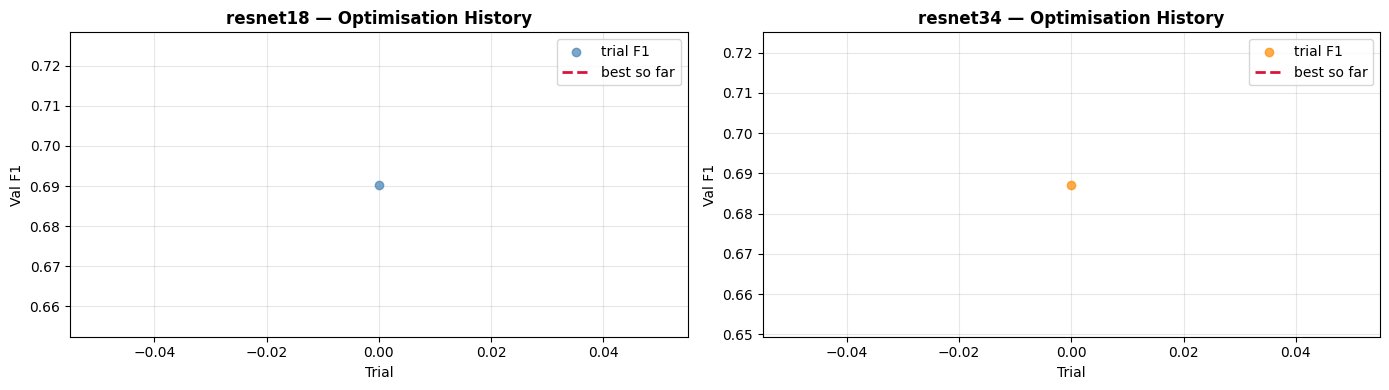

In [30]:
colors = {"resnet18": "steelblue", "resnet34": "darkorange"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, study) in zip(axes, studies.items()):
    completed = [t for t in study.trials if t.value is not None]
    nums   = [t.number for t in completed]
    values = [t.value  for t in completed]
    best_so_far = [max(values[:i+1]) for i in range(len(values))]

    ax.scatter(nums, values, color=colors[name], alpha=0.7, zorder=3, label="trial F1")
    ax.plot(nums, best_so_far, color="crimson", linewidth=2, linestyle="--", label="best so far")
    ax.set_title(f"{name} — Optimisation History", fontweight="bold")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val F1")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6 · Final Training with Best Configs

Full dataset — all 100 folds, 80/20 split (folds 00–79 train, 80–99 test).

In [31]:
FINAL_EPOCHS = 25   # overnight hard version → 50
CLASS_NAMES  = ["Real (wiki)", "Fake (inpainting)"]

final_metrics = {}
final_preds   = {}

for model_name, study in studies.items():
    p = study.best_trial.params
    print(f"\n{'═'*60}")
    print(f"  {model_name.upper()}  opt={p['optimizer']}  lr={p['lr']:.2e}  wd={p['weight_decay']:.2e}")
    print(f"  bs={p['batch_size']}  dropout={p['dropout']:.2f}  label_smoothing={p['label_smoothing']:.2f}")
    print(f"{'═'*60}")
    print(f"  {'Epoch':>5}  {'Acc':>7}  {'Prec':>7}  {'Rec':>7}  {'F1':>7}")
    print(f"  {'─'*37}")

    train_loader, test_loader = make_loaders(p["batch_size"])
    model     = get_model(model_name, dropout=p["dropout"])
    criterion = nn.CrossEntropyLoss(label_smoothing=p["label_smoothing"])
    optimizer = make_optimizer(p["optimizer"], model.parameters(), p["lr"], p["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

    test_accs = []
    for epoch in range(1, FINAL_EPOCHS + 1):
        train_one_epoch(model, train_loader, criterion, optimizer)
        _, y_true, y_pred = evaluate(model, test_loader, criterion)
        m = compute_metrics(y_true, y_pred)
        scheduler.step()
        test_accs.append(m["accuracy"])
        print(f"  {epoch:>5}  {m['accuracy']:>7.4f}  {m['precision']:>7.4f}  {m['recall']:>7.4f}  {m['f1']:>7.4f}")

    _, y_true, y_pred = evaluate(model, test_loader, criterion)
    m = compute_metrics(y_true, y_pred)
    final_metrics[model_name] = {"test_accs": test_accs, **m}
    final_preds[model_name]   = (y_true, y_pred)
    print(f"  {'─'*37}")
    print(f"  Final → acc={m['accuracy']:.4f}  prec={m['precision']:.4f}  rec={m['recall']:.4f}  f1={m['f1']:.4f}")


════════════════════════════════════════════════════════════
  RESNET18  opt=adam  lr=1.33e-04  wd=6.35e-03
  bs=128  dropout=0.43  label_smoothing=0.12
════════════════════════════════════════════════════════════
  Epoch      Acc     Prec      Rec       F1
  ─────────────────────────────────────
      1   0.6301   0.6694   0.5142   0.5816
      2   0.5382   0.5226   0.8836   0.6568
      3   0.5000   0.0000   0.0000   0.0000
      4   0.7373   0.8240   0.6035   0.6968
      5   0.7077   0.6716   0.8131   0.7356
      6   0.8099   0.8709   0.7276   0.7928
      7   0.5643   0.8970   0.1452   0.2500
      8   0.5860   0.9168   0.1892   0.3137
      9   0.5208   0.9055   0.0463   0.0882
     10   0.7047   0.9501   0.4321   0.5941
     11   0.6071   0.6157   0.5699   0.5919
     12   0.5492   0.5426   0.6265   0.5816
     13   0.5804   0.5443   0.9888   0.7021
     14   0.6563   0.9648   0.3244   0.4856
     15   0.8022   0.9310   0.6527   0.7674
     16   0.5324   0.9802   0.0662   0.12

## 7 · Confusion Matrices

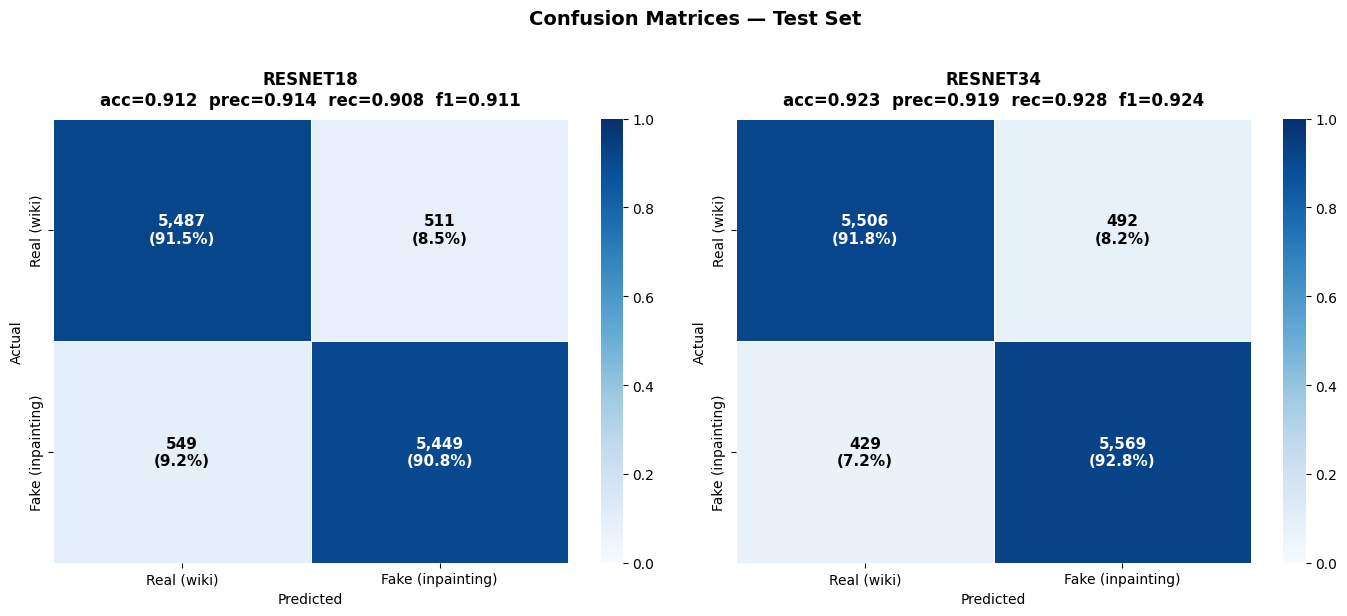

In [32]:
def plot_cm(ax, y_true, y_pred, title):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=False, cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor="white", ax=ax, vmin=0, vmax=1
    )
    for i in range(2):
        for j in range(2):
            c = "white" if cm_norm[i, j] > 0.55 else "black"
            ax.text(j+0.5, i+0.5, f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)",
                    ha="center", va="center", fontsize=11, color=c, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, (y_true, y_pred)) in zip(axes, final_preds.items()):
    m = final_metrics[name]
    plot_cm(ax, y_true, y_pred,
            f"{name.upper()}\nacc={m['accuracy']:.3f}  prec={m['precision']:.3f}  rec={m['recall']:.3f}  f1={m['f1']:.3f}")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8 · Metrics Summary

In [33]:
for name, (y_true, y_pred) in final_preds.items():
    print(f"\n{'─'*45}  {name.upper()}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


─────────────────────────────────────────────  RESNET18
                   precision    recall  f1-score   support

      Real (wiki)       0.91      0.91      0.91      5998
Fake (inpainting)       0.91      0.91      0.91      5998

         accuracy                           0.91     11996
        macro avg       0.91      0.91      0.91     11996
     weighted avg       0.91      0.91      0.91     11996


─────────────────────────────────────────────  RESNET34
                   precision    recall  f1-score   support

      Real (wiki)       0.93      0.92      0.92      5998
Fake (inpainting)       0.92      0.93      0.92      5998

         accuracy                           0.92     11996
        macro avg       0.92      0.92      0.92     11996
     weighted avg       0.92      0.92      0.92     11996



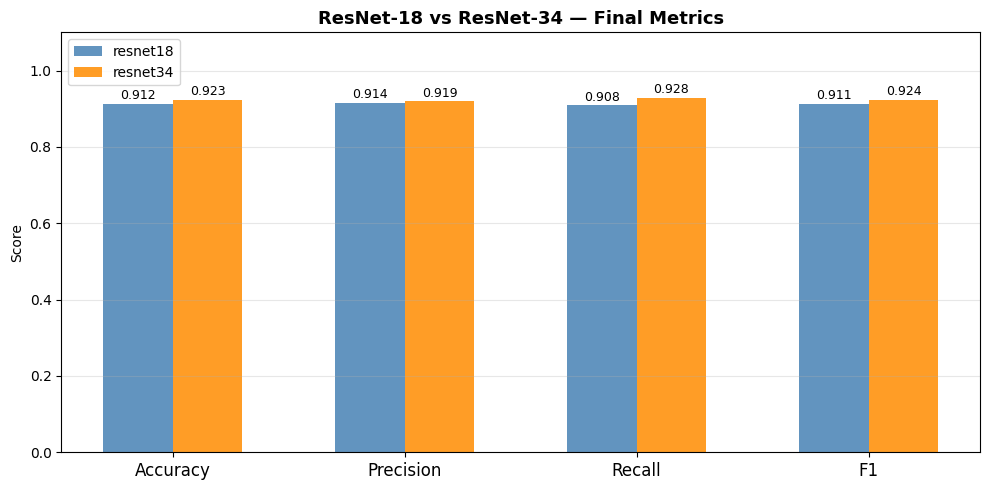

In [34]:
metric_keys = ["accuracy", "precision", "recall", "f1"]
x, width = np.arange(len(metric_keys)), 0.3
fig, ax = plt.subplots(figsize=(10, 5))

for i, name in enumerate(final_metrics):
    vals = [final_metrics[name][k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=name, color=list(colors.values())[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels([k.capitalize() for k in metric_keys], fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("ResNet-18 vs ResNet-34 — Final Metrics", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()